# 🎨 GAN Implementation

## 🚀 Objective
Implement a basic GAN for generating fake face images using the CelebA dataset.

In [1]:
# install required libraries

!pip install torch torchvision matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# import libraries

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

## ⚙️ Device Configuration

In [4]:
# check gpu availability

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


## 📂 Dataset Preparation

In [11]:
# image preprocessing

transform = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(
        (0.5,),
        (0.5,)
    )
])

In [12]:
# load MNIST dataset

dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

100%|██████████| 9.91M/9.91M [00:04<00:00, 2.22MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 87.3kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 893kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 204kB/s]


In [13]:
# create dataloader

dataloader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)

## 🧠 Generator Network

In [14]:
# generator model

class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(100, 256),
            nn.ReLU(),

            nn.Linear(256, 512),
            nn.ReLU(),

            nn.Linear(512, 28 * 28),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)

## 🕵️ Discriminator Network

In [15]:
# discriminator model

class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(28 * 28, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

## ⚙️ Initialize Models

In [16]:
# initialize models

generator = Generator().to(device)

discriminator = Discriminator().to(device)

## 📉 Loss Function and Optimizers

In [17]:
# loss function

criterion = nn.BCELoss()

# optimizers

g_optimizer = optim.Adam(
    generator.parameters(),
    lr=0.0002
)

d_optimizer = optim.Adam(
    discriminator.parameters(),
    lr=0.0002
)

## 🚀 GAN Training Loop

In [22]:
# training loop

num_epochs = 10

for epoch in range(num_epochs):

    for real_images, _ in dataloader:

        batch_size = real_images.size(0)

        # flatten images
        real_images = real_images.view(batch_size, -1).to(device)

        # labels
        real_labels = torch.ones(batch_size, 1).to(device)

        fake_labels = torch.zeros(batch_size, 1).to(device)

        # -------------------------
        # train discriminator
        # -------------------------

        noise = torch.randn(batch_size, 100).to(device)

        fake_images = generator(noise)

        real_outputs = discriminator(real_images)

        fake_outputs = discriminator(fake_images.detach())

        d_loss_real = criterion(real_outputs, real_labels)

        d_loss_fake = criterion(fake_outputs, fake_labels)

        d_loss = d_loss_real + d_loss_fake

        d_optimizer.zero_grad()

        d_loss.backward()

        d_optimizer.step()

        # -------------------------
        # train generator
        # -------------------------

        noise = torch.randn(batch_size, 100).to(device)

        fake_images = generator(noise)

        outputs = discriminator(fake_images)

        g_loss = criterion(outputs, real_labels)

        g_optimizer.zero_grad()

        g_loss.backward()

        g_optimizer.step()

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"D Loss: {d_loss.item():.4f} "
        f"G Loss: {g_loss.item():.4f}"
    )

Epoch [1/10] D Loss: 0.2826 G Loss: 4.2782
Epoch [2/10] D Loss: 0.3225 G Loss: 3.9084
Epoch [3/10] D Loss: 0.0587 G Loss: 6.8647
Epoch [4/10] D Loss: 0.1683 G Loss: 3.5659
Epoch [5/10] D Loss: 0.2177 G Loss: 4.5415
Epoch [6/10] D Loss: 0.2606 G Loss: 4.0705
Epoch [7/10] D Loss: 0.2045 G Loss: 6.8975
Epoch [8/10] D Loss: 0.3441 G Loss: 4.6652
Epoch [9/10] D Loss: 0.3283 G Loss: 3.6457
Epoch [10/10] D Loss: 0.2353 G Loss: 3.4787


## 🎨 Generate Fake Images

In [29]:
# generate fake image

noise = torch.randn(1, 100).to(device)

fake_image = generator(noise)

In [30]:
# reshape generated image

image = fake_image.view(28, 28).detach().cpu()

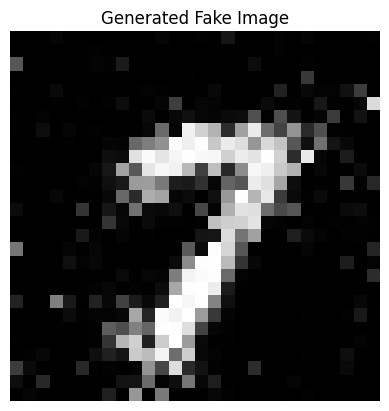

In [31]:
# visualize generated image

plt.imshow(image, cmap="gray")

plt.title("Generated Fake Image")

plt.axis("off")

plt.show()